In [164]:
import xarray as xr
import pandas as pd
import glob
import os
import math

import numpy as np
import re
from joblib import Parallel, delayed



In [38]:
working_dir = '/glade/work/qingyuany/repo_data/'
case_name = "test"
n_sample = 10000


ppe = xr.open_dataset("/glade/work/qingyuany/repo_data/spatialtuning/simv4_iteration1.nc")
obs = xr.open_dataset("/glade/work/qingyuany/repo_data/spatialtuning/obs.nc")


obs_dict = {"SWCF": "swcrf_toa", "LWCF": "lwcrf_toa", "TGCLDLWP": "clwp", "TMQ": "pwv",
          "CLDTOT_ISCCP": "clt_isccp", "FLUT": "olr", "PRECT": "pr","FSNTOA": "swabs_toa"}


In [39]:
para = pd.read_csv("/glade/work/qingyuany/repo_data/spatialtuning/paras_v4.csv", index_col=0)


In [116]:
lab_bin_labels = np.char.add(np.char.add(lat_bins[:-1].astype(str), "to"), lat_bins[1:].astype(str))

In [90]:
man_sel_locations1 = pd.Series({"nm": "SWCF", "lat_min": -6,"lat_max": -4, "lon_min":  141, "lon_max": 144})
man_sel_locations2 = pd.Series({"nm": "SWCF", "lat_min": 7,"lat_max": 9, "lon_min":  235, "lon_max": 240})



manul_ppe_info = pd.concat([man_sel_locations1, man_sel_locations2], axis  = 1).transpose()
manul_ppe_info

,nm,lat_min,lat_max,lon_min,lon_max
0,SWCF,-6,-4,141,144
1,SWCF,7,9,235,240


In [251]:
class TUNING_ITERATION:
    def __init__(self, working_dir, case_name, ppe, obs, obs_dict, para, n_sample = 1000000):
        self.path = os.path.join(working_dir, case_name)

        self.ppe = ppe
        self.obs = obs
        self.obs_dict = obs_dict
        self.para = para
        self.para_nm = list(para.columns)


        para_norm = para.copy()
        para_norm = (para_norm - para_norm.min())/(para_norm.max() - para_norm.min())
        self.para_norm = para_norm


        
        if np.array_equal(ppe.ppe_ind.to_numpy(), para.index.to_numpy()):
            print("Parameter and simulation indices match")
        else:
            print("Indices not matching!")

        if not os.path.exists(self.path):
            os.makedirs(self.path)
            print(f"Created new folder: {self.path}")
            os.makedirs(os.path.join(self.path, 'y_emu'))
            os.makedirs(os.path.join(self.path, 'python_obj'))
            os.makedirs(os.path.join(self.path, 'class_obj'))
            os.makedirs(os.path.join(self.path, 'tabs'))
            print(f'Created four new folders')
        
        else: 
            print("Case already exist")

        para_e = np.random.rand(1000000, len(self.para_nm))
        para_e = pd.DataFrame(para_e, columns=self.para_nm)
        xr.Dataset.from_dataframe(para_e).to_netcdf(os.path.join(self.path, "sampled_parameters.nc"))
        
    def zonalize_obs_ppe(self, lat_bins, manul_ppe_info):
        ppe_zonal_list = []
        obs_zonal_list = []
        
        lab_bin_labels = np.char.add(np.char.add(lat_bins[:-1].astype(str), "to"), lat_bins[1:].astype(str))
        lab_bin_labels = np.char.add("zonal_", lab_bin_labels)
        ############################################################################################################
        for cam_nm, obs_nm in self.obs_dict.items():
        
            ppe_da = self.ppe[cam_nm]
            filter_tf = self.obs[obs_nm].notnull()           ## ## Take out the na values that are in obs from the PPE 
            ppe_da = ppe_da.where(filter_tf)
            
            zonal_ppe_temp = (ppe_da.mean(dim  = "lon", 
                                          skipna = True).groupby_bins("lat",lat_bins, labels = lab_bin_labels).mean(dim = "lat", skipna = True).to_dataframe().unstack(level = 1))
            
            zonal_ppe_temp.columns.name = None # At this point, zonal_ppe_temp has two level in the columns
            zonal_ppe_temp.columns = ["_".join(col) for col in list(zonal_ppe_temp.columns)] # The comprehension unpack the two levels
            
        
            zonal_obs_temp = self.obs[obs_nm].mean(dim = "lon", skipna = True).groupby_bins("lat",lat_bins, labels = lab_bin_labels).mean(dim = "lat", skipna = True).to_series()
            zonal_obs_temp.index = zonal_ppe_temp.columns
        
            
            ppe_zonal_list.append(zonal_ppe_temp)
            obs_zonal_list.append(zonal_obs_temp)
        
        ppe_zonal_pd = pd.concat(ppe_zonal_list, axis = 1)
        obs_zonal_pd = pd.concat(obs_zonal_list)
        
        ############################################################################################################
        
        ppe_manual_list = []
        obs_manual_list = []
        manual_name_list = []

        for row_ind, row in manul_ppe_info.iterrows():
            
            temp_obs = self.obs[obs_dict[row.nm]].sel(lat = slice(row.lat_min, row.lat_max), lon = slice(row.lon_min, row.lon_max)).mean(dim = ["lat", "lon"]).values
            if ~np.isnan(temp_obs):
                temp_ppe = self.ppe[row.nm].sel(lat = slice(row.lat_min, row.lat_max), lon = slice(row.lon_min, row.lon_max)).mean(dim = ["lat", "lon"]).to_dataframe()
                
                manual_name_list.append("_".join(row.astype(str)))
                ppe_manual_list.append(temp_ppe)
                obs_manual_list.append(temp_obs)
            else:
                print("??")        


        ppe_manual_pd = pd.concat(ppe_manual_list,axis = 1)
        obs_manual_pd = pd.Series(obs_manual_list)

        ppe_manual_pd.columns = manual_name_list
        obs_manual_pd.index = manual_name_list
        ############################################################################################################

        ppe_pd = pd.concat([ppe_zonal_pd, ppe_manual_pd], axis = 1)
        obs_pd = pd.concat([obs_zonal_pd, obs_manual_pd])
        
        ppe_pd.to_csv(os.path.join(self.path, "tabs/", "ppe_tab.csv"), index = True)
        obs_pd.to_csv(os.path.join(self.path, "tabs/", "obs_tab.csv"), index=True)
        print("Zonalized and manually selected obs and ppe written as csv")
        self.ppe_pd = ppe_pd
        self.obs_pd = obs_pd

    def load_para_samples(self):
        self.para_s = xr.open_dataset(os.path.join(self.path, "sampled_parameters.nc")).to_dataframe()

    def load_tf_masks(self, threshold_level = 2.0):
        self.tf_masks = pd.read_csv(self.path + "/tf_masks_level" + str(threshold_level) + ".csv", index_col=0)

    def load_y_emu(self, y_name):
        return pd.read_csv(self.path + "/y_emu/" + "gp_mean_std_" + y_name + ".csv", index_col=0)
    
    
    def sensitivity_emulation(self, n_cpus):
        from funs.utils import gp_training_application, fit_gp_for_single_1d, fit_all_gp_models_1d
        
        self.load_para_samples()
        
        
        results = Parallel(n_jobs=n_cpus)(
                        delayed(gp_training_application)(self.para_norm, self.ppe_pd, y_name, self.para_s, path = self.path, n_sens_p=2)
                        for y_name in list(self.ppe_pd.columns)
                    )

        del self.para_s

        meta_xy_dict = {pair[0]: pd.Series(pair[1]) for pair in results if pair is not None}
        meta = pd.concat(list(meta_xy_dict.values()), axis = 1)
        meta.columns = list(meta_xy_dict.keys())
        self.meta = meta

    
    def mask_generation(self, threshold_level = 2.0):
        mean_paths = glob.glob(self.path + "/y_emu/" + "*mean*", recursive=True)

        tf_masks = []

        for path in mean_paths:
            var_name_file = path.split("/")[-1].split("_mean_std_")[1]
            if "zonal" in var_name_file:
                cli_temp = var_name_file.split("_zonal")[0]
                
            else:
                cli_temp = var_name_file.split("_")[0]  #% xxx
                    
            var_name = var_name_file.split(".")[0]
            
            emulated_mean_std = pd.read_csv(path,index_col=0)
            emulated_mean = emulated_mean_std.iloc[:,0]
            emulated_std = emulated_mean_std.iloc[:,1]            
            
            obs_temp = self.obs_pd.loc[var_name]
            y_ppe = self.ppe_pd[var_name]
        
            yscale = y_ppe.std()
            ymu = y_ppe.mean()            
            emulated_mean = emulated_mean * yscale + ymu
            emulated_std = emulated_std * yscale
            
            temp_tf_mask = ((emulated_mean - threshold_level * emulated_std) < obs_temp) & ((emulated_mean + threshold_level * emulated_std) > obs_temp)
            temp_tf_mask.name = var_name
            tf_masks.append(temp_tf_mask)


        tf_masks = pd.concat(tf_masks, axis = 1)
        tf_masks.to_csv(self.path + "/tf_masks_level" + str(threshold_level) + ".csv")
        

In [253]:
test_case = TUNING_ITERATION(working_dir, case_name, ppe, obs, obs_dict, para)

Parameter and simulation indices match
Created new folder: /glade/work/qingyuany/repo_data/test
Created four new folders


In [254]:
test_case.zonalize_obs_ppe(lat_bins, manul_ppe_info)

Zonalized and manually selected obs and ppe written as csv


In [255]:
test_case.sensitivity_emulation(n_cpus = 16)

/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn

In [256]:
test_case.mask_generation(threshold_level = 2.0)

In [257]:
test_case.load_tf_masks(threshold_level=2.0)

,SWCF_zonal_-85to-80,SWCF_zonal_-80to-75,SWCF_zonal_-75to-70,SWCF_zonal_-70to-65,SWCF_zonal_-65to-60,SWCF_zonal_-60to-55,SWCF_zonal_-55to-50,SWCF_zonal_-50to-45,SWCF_zonal_-45to-40,SWCF_zonal_-40to-35,...,FSNTOA_zonal_45to50,FSNTOA_zonal_50to55,FSNTOA_zonal_55to60,FSNTOA_zonal_60to65,FSNTOA_zonal_65to70,FSNTOA_zonal_70to75,FSNTOA_zonal_75to80,FSNTOA_zonal_80to85,SWCF_-6_-4_141_144,SWCF_7_9_235_240
ppe_ind,,,,,,,,,,,,,,,,,,,,,
1,-1.775323,-3.677040,-8.188253,-26.007094,-55.478150,-73.107625,-77.024634,-73.212884,-64.607686,-54.185431,...,191.494925,167.835081,146.375524,122.742515,102.767963,87.831024,76.362725,71.129395,-128.715744,-87.976289
3,-1.618221,-3.374800,-8.302124,-26.239062,-55.215606,-72.102811,-75.852205,-72.355755,-63.536108,-53.471915,...,194.268145,172.547603,151.700622,128.713602,106.657581,88.535728,76.195900,70.599075,-104.409674,-89.894234
4,-1.765804,-3.844527,-8.594140,-27.004102,-56.849576,-74.685015,-78.965654,-77.357821,-74.099307,-67.848767,...,190.954915,167.326394,146.043029,123.389661,103.185150,86.342926,74.753110,69.292476,-125.420282,-102.611100
5,-2.353393,-4.225666,-8.897521,-27.351285,-56.519404,-73.319435,-76.810730,-74.351819,-69.418165,-63.010395,...,189.980311,167.055944,144.121663,121.062649,100.773901,85.780473,74.181953,68.465038,-131.558543,-77.443123
6,-1.377978,-3.060643,-7.356543,-24.552219,-52.189145,-68.319704,-71.086715,-68.272482,-62.101780,-52.859389,...,192.232098,169.226385,148.078477,125.528020,104.687790,88.765484,76.183082,70.918957,-103.527699,-53.324356
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,-1.606898,-3.169294,-7.590625,-24.659385,-52.536696,-70.074936,-74.534792,-72.147591,-66.729659,-58.851437,...,191.785045,168.880275,148.193329,125.965657,105.759482,89.755159,76.766980,71.336729,-121.412717,-101.191075
87,-1.762400,-3.385148,-8.145162,-25.911908,-53.455347,-69.577070,-72.606119,-67.930465,-58.418597,-47.882339,...,192.230229,169.830748,150.502504,128.606907,107.295776,89.477132,75.771006,69.534858,-105.989846,-73.850319
88,-2.018235,-3.873849,-9.167514,-27.983393,-57.934004,-76.453763,-82.638755,-82.466202,-79.755906,-74.506072,...,187.435599,164.405076,142.687810,120.382901,101.676793,87.635764,76.365598,71.120905,-130.176916,-104.578004


In [266]:
test_case.tf_masks.sum(axis = 0).sort_values().iloc[90:100]

TGCLDLWP_zonal_-65to-60        11893
TGCLDLWP_zonal_10to15          17655
FSNTOA_zonal_-75to-70          39275
FSNTOA_zonal_80to85            40333
TGCLDLWP_zonal_0to5            43635
TGCLDLWP_zonal_-75to-70        56638
CLDTOT_ISCCP_zonal_-50to-45    80428
CLDTOT_ISCCP_zonal_-35to-30    94715
CLDTOT_ISCCP_zonal_-45to-40    94962
CLDTOT_ISCCP_zonal_-30to-25    96585
dtype: int64

In [268]:
yname = "CLDTOT_ISCCP_zonal_-45to-40"
y_temp = test_case.load_y_emu(yname).iloc[:,0]

In [281]:
test_case.load_para_samples()

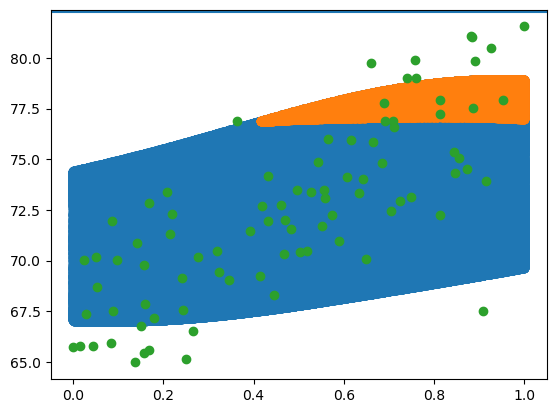

In [285]:
import matplotlib.pyplot as plt
plt.scatter(test_case.para_s.iloc[:,9], y_temp * test_case.ppe_pd[yname].std() + test_case.ppe_pd[yname].mean())
plt.scatter(test_case.para_s.iloc[:,9][test_case.tf_masks[yname]], y_temp[test_case.tf_masks[yname]] * test_case.ppe_pd[yname].std() + test_case.ppe_pd[yname].mean())



plt.scatter(test_case.para_norm.iloc[:,8], test_case.ppe_pd[yname])
plt.axhline(test_case.obs_pd.loc[yname])


In [276]:
test_case.obs_pd.loc[yname]

82.25299990544022